In [5]:
import geopandas as gpd

# Load the cross-validation file
file_path = 'predicted_shorelines_cut_crossval.geojson'
gdf = gpd.read_file(file_path)

# Print the first 5 rows and the column names to identify the 'fold' identifier
print("--- Columns available ---")
print(gdf.columns)

print("\n--- First 5 rows to check values ---")
print(gdf.head())

--- Columns available ---
Index(['site', 'date', 'timezone', 'experimentname', 'image_type',
       'verticaldatum', 'geometry'],
      dtype='object')

--- First 5 rows to check values ---
   site                      date timezone          experimentname image_type  \
0  cies 2018-05-06 14:01:00+00:00      UTC  fold0_DeepLabV3512x512    oblique   
1  cies 2018-08-10 06:33:46+00:00      UTC  fold0_DeepLabV3512x512    oblique   
2  cies 2018-08-12 09:20:54+00:00      UTC  fold0_DeepLabV3512x512    oblique   
3  cies 2018-08-19 10:48:44+00:00      UTC  fold0_DeepLabV3512x512    oblique   
4  cies 2018-09-03 12:48:00+00:00      UTC  fold0_DeepLabV3512x512    oblique   

  verticaldatum                                           geometry  
0          NMMA  MULTIPOINT Z ((-8.90133 42.22566 0.6322), (-8....  
1          NMMA  MULTIPOINT Z ((-8.90122 42.22561 -0.79614), (-...  
2          NMMA  MULTIPOINT Z ((-8.90126 42.22563 -0.30758), (-...  
3          NMMA  MULTIPOINT Z ((-8.90132 42.225

In [14]:
import geopandas as gpd
import pandas as pd
import numpy as np

# ==========================================
# 1. HELPER FUNCTIONS (Reusable logic)
# ==========================================

def count_points(geom):
    """
    Counts the number of points/vertices in a geometry.
    Supports MultiPoint (shorelines) and LineString.
    """
    if geom is None:
        return 0
    if geom.geom_type == 'MultiPoint':
        return len(geom.geoms)
    elif geom.geom_type == 'LineString':
        return len(geom.coords)
    else:
        return 0

def display_metrics(df, label, indent=""):
    """
    Internal helper to print the actual numbers.
    Used for both Global stats and Per-Site stats.
    """
    num_lines = len(df)
    mean_pts = df['point_count'].mean()
    max_pts = df['point_count'].max()
    min_pts = df['point_count'].min()
    std_pts = df['point_count'].std()

    print(f"{indent}--- {label} ---")
    print(f"{indent}Number of Shorelines (N): {num_lines}")
    print(f"{indent}Average Points per Line : {mean_pts:.2f}")
    print(f"{indent}Max Points in a Line    : {max_pts}")
    print(f"{indent}Min Points in a Line    : {min_pts}")
    print(f"{indent}Standard Deviation (SD) : {std_pts:.2f}")
    print(f"{indent}" + "-" * 30)

def print_dataset_stats(gdf, main_title):
    """
    Calculates and prints stats:
    1. Globally (Total for this selection)
    2. Broken down by 'site' (if available)
    """
    print(f"\n>>> ANALYZING: {main_title}")
    print("=" * 60)
    
    if gdf.empty:
        print(">> Warning: No data found for this selection.\n")
        return

    # 1. Pre-calculate points for the whole set (Efficiency)
    # We use copy() to avoid SettingWithCopyWarning
    df_calc = gdf.copy()
    df_calc['point_count'] = df_calc.geometry.apply(count_points)

    # 2. Display GLOBAL stats
    display_metrics(df_calc, "GLOBAL STATS (All sites combined)")

    # 3. Display PER-SITE stats
    if 'site' in df_calc.columns:
        # Get unique sites sorted alphabetically
        unique_sites = sorted(df_calc['site'].unique())
        
        if len(unique_sites) > 0:
            print(f"\n   [ BREAKDOWN BY SITE ({len(unique_sites)} found) ]")
            
            for site in unique_sites:
                # Filter data for this specific site
                site_subset = df_calc[df_calc['site'] == site]
                
                # Display stats with indentation for readability
                display_metrics(site_subset, f"SITE: {site.upper()}", indent="   ")
    else:
        print("   (No 'site' column found, skipping site breakdown)")
    
    print("=" * 60 + "\n")

def load_file(file_path):
    """
    Safe file loading wrapper.
    """
    print(f"Please wait, loading: {file_path} ...")
    try:
        return gpd.read_file(file_path)
    except Exception as e:
        print(f"!! Error loading file: {e}")
        return None

# ==========================================
# 2. ANALYSIS WORKFLOWS
# ==========================================

def analyze_baseline(file_path):
    """
    Workflow for the Baseline file (analyzes the whole file).
    """
    print(f"\n******************************************")
    print(f" PROCESSING FILE: BASELINE")
    print(f"******************************************")
    
    gdf = load_file(file_path)
    if gdf is not None:
        print_dataset_stats(gdf, "BASELINE FULL DATASET")

def analyze_crossval_fold(file_path, fold_name):
    """
    Workflow for Crossval file:
    1. Filters by specific Fold (experimentname).
    2. Splits by Image Type (Oblique vs Rectified).
    """
    print(f"\n******************************************")
    print(f" PROCESSING FILE: CROSSVAL")
    print(f" FOLD TARGET: {fold_name}")
    print(f"******************************************")
    
    gdf = load_file(file_path)
    
    if gdf is not None:
        # 1. Filter by Fold
        if 'experimentname' not in gdf.columns:
            print("Error: 'experimentname' column missing.")
            return

        fold_subset = gdf[gdf['experimentname'] == fold_name].copy()
        
        if fold_subset.empty:
            print(f"Error: No data found for fold '{fold_name}'. Check spelling.")
            return

        # 2. Split by Image Type
        if 'image_type' in fold_subset.columns:
            # A) OBLIQUE
            oblique = fold_subset[fold_subset['image_type'] == 'oblique']
            print_dataset_stats(oblique, f"FOLD: {fold_name} | TYPE: OBLIQUE")
            
            # B) RECTIFIED
            rectified = fold_subset[fold_subset['image_type'] == 'rectified']
            print_dataset_stats(rectified, f"FOLD: {fold_name} | TYPE: RECTIFIED")
        else:
            print("Warning: 'image_type' column missing. Analyzing total fold instead.")
            print_dataset_stats(fold_subset, f"FOLD: {fold_name} (Total)")

# ==========================================
# 3. EXECUTION BLOCK
# ==========================================

if __name__ == "__main__":
    
    # --- CONFIGURATION ---
    FILE_BASELINE = 'predicted_shorelines_cut_baseline.geojson'
    FILE_CROSSVAL = 'predicted_shorelines_cut_crossval.geojson'
    
    TARGET_FOLD_NAME = "fold1_DeepLabV3512x512" 
    # Change TARGET_FOLD_NAME to "fold1_DeepLabV3512x512" etc.
    
    # --- RUN ---
    
    # 1. Run Baseline Analysis
    analyze_baseline(FILE_BASELINE)
    
    # 2. Run Crossval Analysis (Fold + Split types)
    analyze_crossval_fold(FILE_CROSSVAL, TARGET_FOLD_NAME)


******************************************
 PROCESSING FILE: BASELINE
******************************************
Please wait, loading: predicted_shorelines_cut_baseline.geojson ...

>>> ANALYZING: BASELINE FULL DATASET
--- GLOBAL STATS (All sites combined) ---
Number of Shorelines (N): 174
Average Points per Line : 58.46
Max Points in a Line    : 168
Min Points in a Line    : 5
Standard Deviation (SD) : 27.07
------------------------------

   [ BREAKDOWN BY SITE (5 found) ]
   --- SITE: AGRELO ---
   Number of Shorelines (N): 25
   Average Points per Line : 57.12
   Max Points in a Line    : 59
   Min Points in a Line    : 42
   Standard Deviation (SD) : 3.69
   ------------------------------
   --- SITE: ARENALDENTEM ---
   Number of Shorelines (N): 4
   Average Points per Line : 48.50
   Max Points in a Line    : 50
   Min Points in a Line    : 47
   Standard Deviation (SD) : 1.29
   ------------------------------
   --- SITE: CADIZ ---
   Number of Shorelines (N): 95
   Average Po

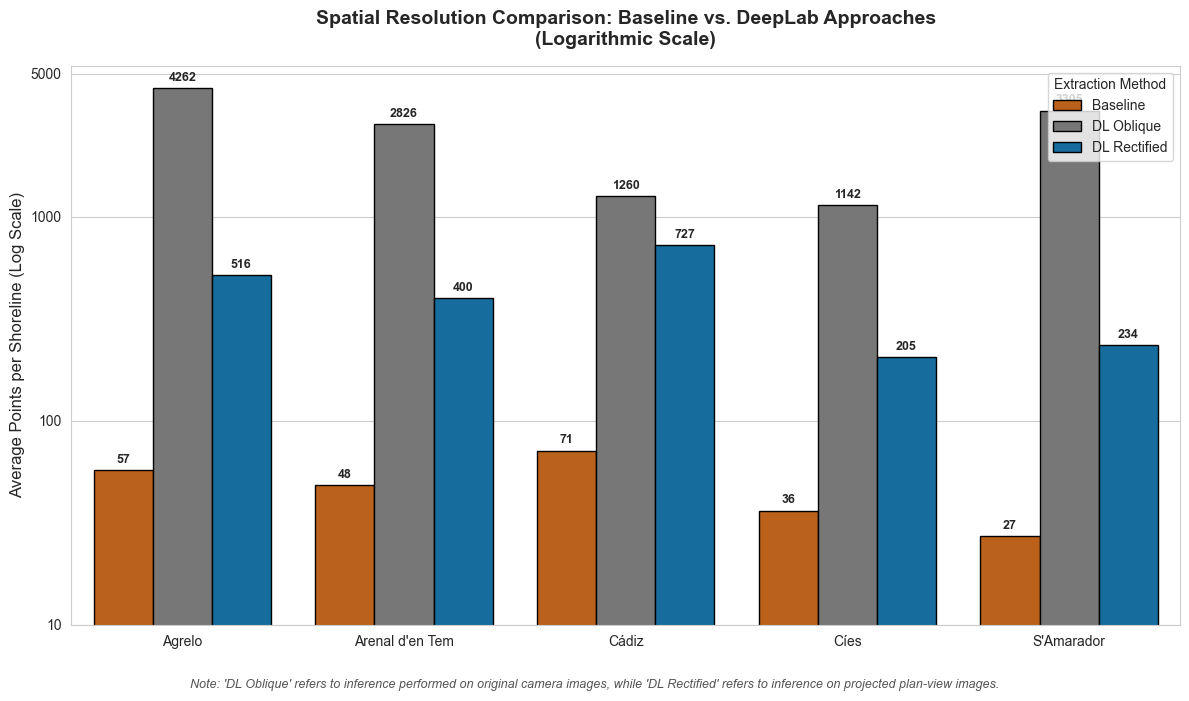

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.ticker as ticker

# 1. DATA PREPARATION
# ---------------------------------------------------------
# Comparison of three different sources/methods of shoreline extraction
data = {
    'Site': ['Agrelo', "Arenal d'en Tem", 'Cádiz', 'Cíes', "S'Amarador"],
    
    # 1. Baseline: Manual or CoastSnap standard extraction
    'Baseline': [57.12, 48.50, 71.44, 36.36, 27.17],
    
    # 2. DL Method A: Prediction on Oblique Images (Camera Perspective)
    # High point density due to perspective distortion and native image resolution.
    'DL Oblique': [4262.44, 2826.50, 1260.03, 1141.70, 3305.33],
    
    # 3. DL Method B: Prediction on Rectified Images (Plan View)
    # Optimized point density working directly in metric space.
    'DL Rectified': [515.64, 400.50, 727.20, 205.02, 234.00]
}

df_points = pd.DataFrame(data)

# Transform data to long format for Seaborn plotting
df_melted = df_points.melt(id_vars='Site', var_name='Method', value_name='Points')

# 2. PLOT CONFIGURATION
# ---------------------------------------------------------
sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(12, 7))

# Color palette strategy:
# Baseline: Red/Orange (Reference)
# DL Oblique: Grey (High density method)
# DL Rectified: Blue (Balanced method)
colors = {
    'Baseline': '#D55E00',    # Vermillion
    'DL Oblique': '#777777',  # Dark Grey
    'DL Rectified': '#0072B2' # Blue
}

# Create the Bar Plot
bars = sns.barplot(
    data=df_melted, 
    x='Site', 
    y='Points', 
    hue='Method', 
    palette=colors,
    edgecolor='black',
    linewidth=1,
    ax=ax
)

# 3. APPLY LOG SCALE
# ---------------------------------------------------------
# A logarithmic scale is essential because 'DL Oblique' values (~3000 pts) 
# are orders of magnitude larger than 'Baseline' (~30 pts).
ax.set_yscale('log')

# 4. ADD VALUE LABELS
# ---------------------------------------------------------
# Loop through the bars to display the exact point count
for container in bars.containers:
    labels = [f'{v:.0f}' for v in container.datavalues]
    
    ax.bar_label(
        container, 
        labels=labels, 
        padding=3, 
        fontsize=9, 
        fontweight='bold'
    )

# 5. FINAL AESTHETICS AND LABELS
# ---------------------------------------------------------
ax.set_title(
    'Spatial Resolution Comparison: Baseline vs. DeepLab Approaches\n(Logarithmic Scale)', 
    fontsize=14, fontweight='bold', pad=15
)
ax.set_ylabel('Average Points per Shoreline (Log Scale)', fontsize=12)
ax.set_xlabel('')

# Format Y-axis to show real numbers (10, 100, 1000) instead of powers of 10
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_yticks([10, 100, 1000, 5000])

# Update Legend to describe the methods
ax.legend(title='Extraction Method', loc='upper right', bbox_to_anchor=(1, 1))

# Add a footnote clarifying the difference between approaches
plt.figtext(0.5, 0.01, 
            "Note: 'DL Oblique' refers to inference performed on original camera images, while 'DL Rectified' refers to inference on projected plan-view images.", 
            ha="center", fontsize=9, style='italic', color='#555555')

plt.tight_layout()
plt.subplots_adjust(bottom=0.1) # Make space for the footnote

plt.show()
# fig.savefig('resolution_comparison_methods.png', dpi=300)